In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

def objfun(fenotipo):
    x = fenotipo[:, 0]
    y = fenotipo[:, 1]
    return (21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)).reshape(-1, 1)

In [6]:
np.random.seed(42)

Nind = 100
Lind = 33
Pc = 0.9
Pm = 0.01
Maxgen = 1000
Nvar = 2

rango = np.array([
    [-3.0, 12.1],
    [4.1, 5.8]
], dtype=float)

In [7]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind), dtype=int)

genotipo = creapob(Nind, Lind)
genotipo[:5]

array([[0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1],
       [1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
        0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1]])

In [8]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar

    fenotipo = np.zeros((Nind, Nvar), dtype=float)

    for j in range(Nvar):
        bits = genotipo[:, j * Lvar:(j + 1) * Lvar]
        pesos = 2 ** np.arange(Lvar - 1, -1, -1)
        decimal = bits @ pesos

        li = rango[j, 0]
        ls = rango[j, 1]
        fenotipo[:, j] = li + (decimal * (ls - li)) / (2 ** Lvar - 1)

    return fenotipo

fenotipo = decodifica(genotipo, rango)
fenotipo[:5]

array([[ 1.02620584,  5.66710765],
       [ 9.29773861,  5.2355642 ],
       [ 8.1751751 ,  4.60466926],
       [ 0.76538033,  5.30339818],
       [-2.95760433,  4.53380026]])

In [9]:
objv = objfun(fenotipo)
objv[:5]

array([[16.8473899 ],
       [20.37478988],
       [29.43488071],
       [22.47675722],
       [23.85599609]])

In [10]:
def rankeo(objv, direccion=1):
    SP = 2.0
    Nind = objv.shape[0]
    aptitud = np.zeros((Nind, 1), dtype=float)

    valores = objv.flatten()

    if direccion == 1:
        orden = np.argsort(valores)
    else:
        orden = np.argsort(-valores)

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    aptitud[orden, 0] = apt

    return aptitud

In [11]:
def ruleta(genotipo, aptitud):
    Nind = genotipo.shape[0]
    total = np.sum(aptitud)

    probabilidad = (aptitud / total).flatten()
    acumulada = np.cumsum(probabilidad)

    idx = np.zeros(Nind, dtype=int)

    for i in range(Nind):
        r = np.random.rand()
        idx[i] = np.searchsorted(acumulada, r)

    return genotipo[idx, :].copy()

In [12]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            hijo1 = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            hijo2 = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
            aux_gen[i, :] = hijo1
            aux_gen[i + 1, :] = hijo2

    return aux_gen

In [13]:
def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    mascara = np.random.rand(Nind, Lind) <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

In [14]:
Mejor = np.full((Maxgen, 1), np.nan)
Mejor_fenotipo = np.zeros((Maxgen, Nvar))
Mejor_cromosoma = np.zeros((Maxgen, Lind), dtype=int)

for gen in range(Maxgen):
    fenotipo = decodifica(genotipo, rango)
    objv = objfun(fenotipo)

    idx = np.argmax(objv)
    Mejor[gen] = objv[idx]
    Mejor_fenotipo[gen] = fenotipo[idx]
    Mejor_cromosoma[gen] = genotipo[idx]

    aptitud = rankeo(objv)
    nuevo_gen = ruleta(genotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)

    genotipo = nuevo_gen

In [15]:
idx_global = np.argmax(Mejor)

print("Mejor generación:", idx_global)
print("Mejor valor:", Mejor[idx_global, 0])
print("Mejor x:", Mejor_fenotipo[idx_global, 0])
print("Mejor y:", Mejor_fenotipo[idx_global, 1])
print("Mejor cromosoma:", Mejor_cromosoma[idx_global])

Mejor generación: 150
Mejor valor: 38.450261132476435
Mejor x: 11.62535286488136
Mejor y: 5.325058365758755
Mejor cromosoma: [1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 0 0]


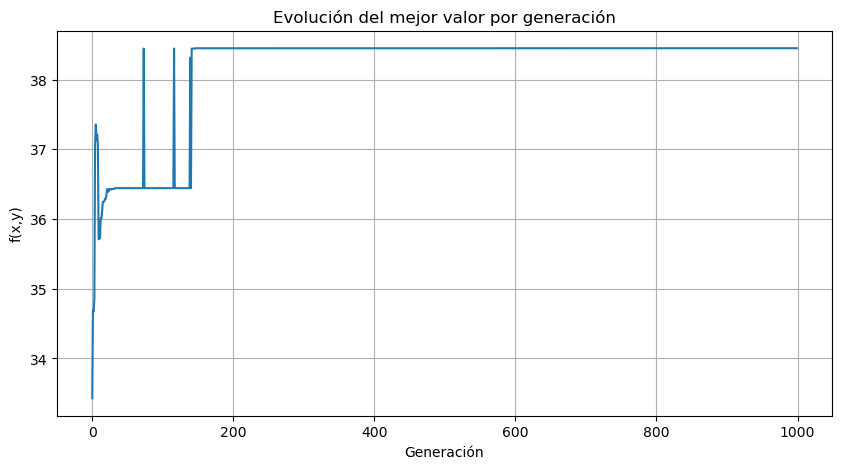

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(Mejor)
plt.title("Evolución del mejor valor por generación")
plt.xlabel("Generación")
plt.ylabel("f(x,y)")
plt.grid(True)
plt.show()

In [17]:
x = np.linspace(-3.0, 12.1, 200)
y = np.linspace(4.1, 5.8, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

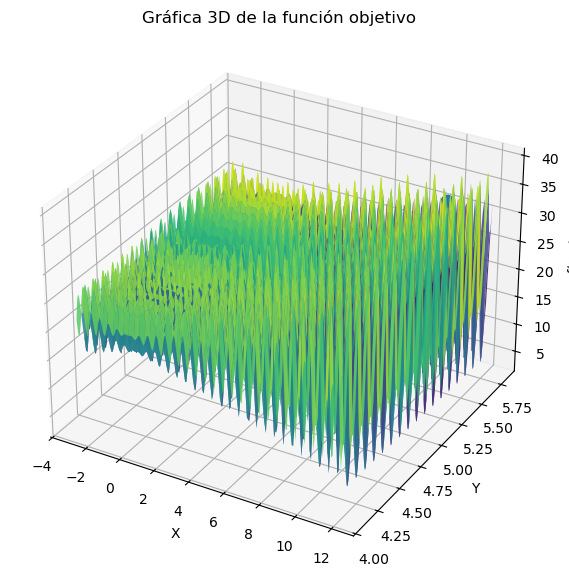

In [18]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
ax.scatter(
    Mejor_fenotipo[idx_global, 0],
    Mejor_fenotipo[idx_global, 1],
    Mejor[idx_global, 0],
    s=80
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x,y)')
ax.set_title('Gráfica 3D de la función objetivo')

plt.show()

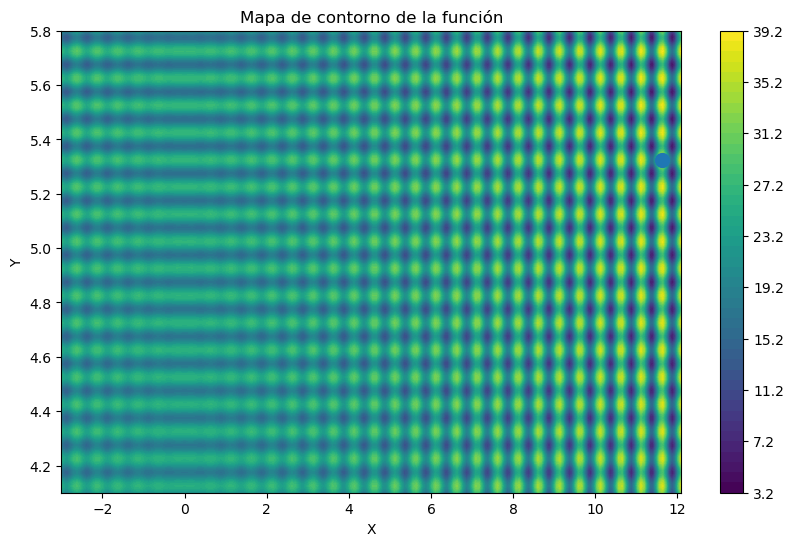

In [19]:
plt.figure(figsize=(10, 6))
cont = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(cont)
plt.scatter(
    Mejor_fenotipo[idx_global, 0],
    Mejor_fenotipo[idx_global, 1],
    s=100
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de contorno de la función")
plt.show()